# Landsat 8 OLI download for Alegre, Brazil

This notebook uses the [USGS Landsat Collection 2 dataset on AWS](https://registry.opendata.aws/usgs-landsat/index.html)
to locate and download an OLI/TIRS Level-1 scene covering Alegre, Espírito Santo, Brazil
for 1 July 2025. The workflow stays within AWS public resources so the assets can be pulled
directly from the `usgs-landsat` bucket.

In [25]:
from pathlib import Path
import os
import json
import boto3
from botocore.config import Config
from botocore import UNSIGNED

import requests

target_latitude = -20.7589
target_longitude = -41.5387
spatial_buffer_degrees = 0.05
start_time_iso = "2025-07-01T00:00:00Z"
end_time_iso = "2025-07-02T00:00:00Z"
bbox = [
    target_longitude - spatial_buffer_degrees,
    target_latitude - spatial_buffer_degrees,
    target_longitude + spatial_buffer_degrees,
    target_latitude + spatial_buffer_degrees,
]

stac_api_root = "https://landsatlook.usgs.gov/stac-server"
collection_id = "landsat-c2l1"
local_download_dir = Path('../data') / 'landsat' / 'alegre_2025-07-01'
local_download_dir.mkdir(parents=True, exist_ok=True)
s3_bucket_name = 'usgs-landsat'
s3_client = boto3.client('s3')

landsatlook_token = os.environ.get('LANDSATLOOK_TOKEN')
if not landsatlook_token:
    raise RuntimeError('Set LANDSATLOOK_TOKEN in your environment to access landsatlook.usgs.gov.')
stac_headers = {'Authorization': f'Bearer {landsatlook_token}'}

requested_assets = [
    'reduced_resolution_browse',
    'green', 'red','blue',
     # 'nir08', 'swir16', 'swir22', 'qa_pixel', 'MTL.txt'
]


reduced_resolution_browse (true-color JPEG at ~300 m resolution) 

nir08: Near-infrared band (0.85–0.88 µm). Highly reflective for healthy vegetation, so it’s the key input for NDVI-style indices and helps delineate forest cover and canopy vigor.

swir16: Shortwave infrared band around 1.6 µm. Sensitive to moisture and lignin/cellulose content, making it useful for assessing vegetation and soil moisture and distinguishing bare soil vs. forest.

swir22: Longer SWIR band near 2.2 µm. Strongly influenced by water content and mineralogy, helping separate forested areas from dry soils or burned surfaces and improving biomass assessments.

qa_pixel: Pixel quality assurance bitmask. Encodes per-pixel flags such as clouds, cloud shadows, snow/ice, and fill values so you can mask unreliable pixels before analysis.

In [26]:
search_url = f"{stac_api_root}/search"
search_payload = {
    'bbox': bbox,
    'collections': [collection_id],
    'datetime': f"{start_time_iso}/{end_time_iso}",
    'limit': 5,
    'sortby': [{
        'field': 'properties.datetime',
        'direction': 'asc',
    }],
}
stac_response = requests.post(search_url, json=search_payload, headers=stac_headers, timeout=90)
stac_response.raise_for_status()
stac_json = stac_response.json()
features = stac_json.get('features', [])
if not features:
    raise RuntimeError('No matching Landsat 8 scenes for Alegre on 2025-07-01.')
chosen_feature = features[0]
chosen_id = chosen_feature['id']
chosen_datetime = chosen_feature['properties']['datetime']
path_value = chosen_feature['properties'].get('wrs_path')
row_value = chosen_feature['properties'].get('wrs_row')
path_row = f"{path_value:03d}/{row_value:03d}" if path_value is not None and row_value is not None else 'unknown'
available_assets = list(chosen_feature['assets'].keys())
print('Scene ID:', chosen_id)
print('Acquisition datetime:', chosen_datetime)
print('WRS Path/Row:', path_row)
print('Available asset keys:', ', '.join(available_assets))


Scene ID: LC08_L1GT_098170_20250701_20250711_02_T2
Acquisition datetime: 2025-07-01T01:13:51.521113Z
WRS Path/Row: unknown
Available asset keys: thumbnail, reduced_resolution_browse, index, MTL.json, coastal, blue, green, red, nir08, swir16, swir22, pan, cirrus, lwir11, lwir12, qa_pixel, qa_radsat, ANG.txt, VAA, VZA, SAA, SZA, MTL.txt, MTL.xml


In [27]:
requested_assets

['reduced_resolution_browse', 'green', 'red', 'blue']

In [28]:
assets_to_fetch = []
for asset_key in requested_assets:
    if asset_key in chosen_feature['assets']:
        assets_to_fetch.append((asset_key, chosen_feature['assets'][asset_key]['href']))
if not assets_to_fetch:
    raise RuntimeError('None of the requested asset keys are available in the selected STAC item.')
download_manifest = []
for asset_name, asset_href in assets_to_fetch:
    object_key = None
    if asset_href.startswith('s3://usgs-landsat/'):
        object_key = asset_href.replace('s3://usgs-landsat/', '')
    elif asset_href.startswith('http') and 'landsatlook.usgs.gov' in asset_href:
        parts = asset_href.split('/data/', 1)
        if len(parts) == 2:
            object_key = parts[1].lstrip('/')
    if not object_key:
        raise ValueError(f'Unsupported asset location: {asset_href}')
    download_reference = f"s3://{s3_bucket_name}/{object_key}"
    suffix = Path(object_key).suffix or f'_{asset_name.lower()}'
    destination = local_download_dir / f"{chosen_id}_{asset_name}{suffix}"
    print(f"Downloading {asset_name} from {download_reference}")
    print(f"s3_client.download_file(Bucket={s3_bucket_name!r}, Key={object_key!r}, Filename={destination.as_posix()!r})")
    s3_client.download_file(s3_bucket_name, object_key, destination.as_posix(), ExtraArgs={"RequestPayer": "requester"})
    download_manifest.append({
        'asset': asset_name,
        'path': destination.as_posix(),
        'size_bytes': destination.stat().st_size,
    })
print(json.dumps(download_manifest, indent=2))


s3_client.download_file(Bucket='usgs-landsat', Key='collection02/level-1/standard/oli-tirs/2025/098/170/LC08_L1GT_098170_20250701_20250711_02_T2/LC08_L1GT_098170_20250701_20250711_02_T2_thumb_large.jpeg', Filename='../data/landsat/alegre_2025-07-01/LC08_L1GT_098170_20250701_20250711_02_T2_reduced_resolution_browse.jpeg')
s3_client.download_file(Bucket='usgs-landsat', Key='collection02/level-1/standard/oli-tirs/2025/098/170/LC08_L1GT_098170_20250701_20250711_02_T2/LC08_L1GT_098170_20250701_20250711_02_T2_B3.TIF', Filename='../data/landsat/alegre_2025-07-01/LC08_L1GT_098170_20250701_20250711_02_T2_green.TIF')
s3_client.download_file(Bucket='usgs-landsat', Key='collection02/level-1/standard/oli-tirs/2025/098/170/LC08_L1GT_098170_20250701_20250711_02_T2/LC08_L1GT_098170_20250701_20250711_02_T2_B4.TIF', Filename='../data/landsat/alegre_2025-07-01/LC08_L1GT_098170_20250701_20250711_02_T2_red.TIF')
s3_client.download_file(Bucket='usgs-landsat', Key='collection02/level-1/standard/oli-tirs/2025

Around 2.2s  to download reduced_resolution
and ~8s for each green, blue, red. 

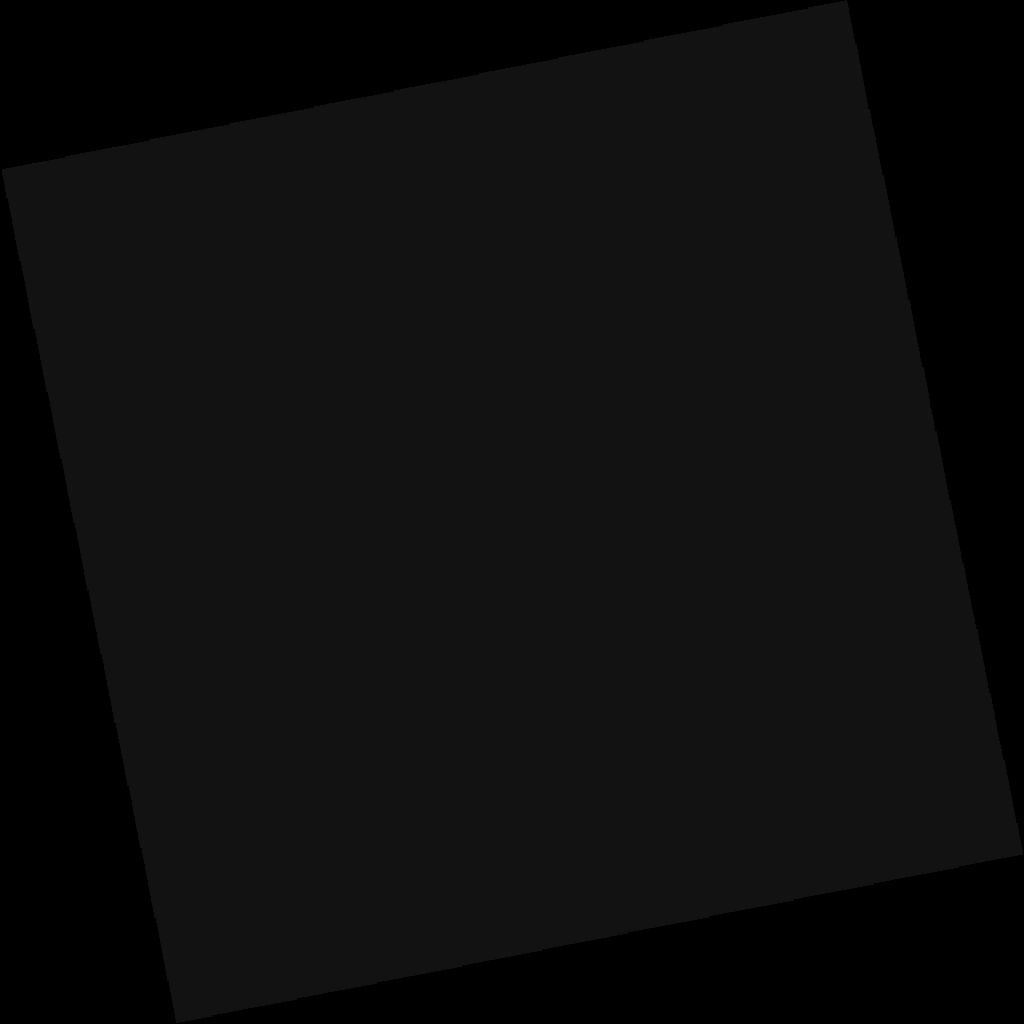

In [29]:
from PIL import Image
from IPython.display import display

browse_image = local_download_dir / 'LC08_L1GT_098170_20250701_20250711_02_T2_reduced_resolution_browse.jpeg'
if not browse_image.exists():
    raise FileNotFoundError(f'Expected browse image not found at {browse_image}')
display(Image.open(browse_image))
